In [2]:
import os
os.chdir("C:/Users/dc200/Code_adventure/CNN")
os.getcwd()

'C:\\Users\\dc200\\Code_adventure\\CNN'

In [9]:
from cnn.training import Training
from cnn.testing import Testing
from cnn.loss import Loss
from cnn.activation import Activation
from cnn.dense import Dense
from cnn.model import Model
from cnn.flattening import Flattening
from cnn.convolution import Convolutional
from cnn.pooling import MaxPool, MeanPool

lr = 0.6
dataset = "mnist"

layers = [
    Convolutional(32, 4, padding=2, stride=2),
    Activation("sigmoid"),
    Flattening(),
    Dense(32),
    Dense(10)
]

model = Model(layers, Loss("CEL"), dataset)

test = Testing(dataset, model)

trainer = Training(dataset, model, test, batch_size=32, learning_rate=lr, lr_decay="exponential", lambda_rate=0.1)


In [10]:

print("Initial test", test.exam())


Initial test 10.12


In [11]:
trainer.SGD(10)
print("After training test", test.exam())

Epochs: 100%|██████████| 10/10 [19:16<00:00, 115.63s/it]


After training test 11.35


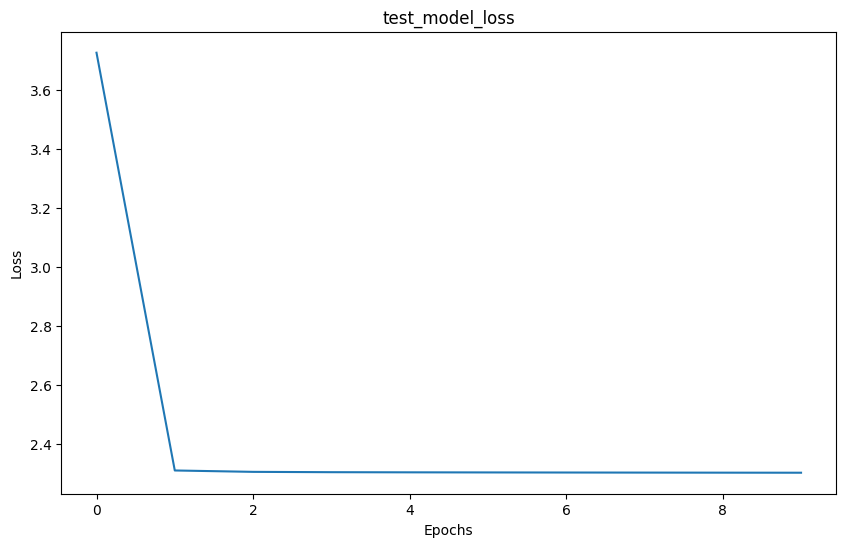

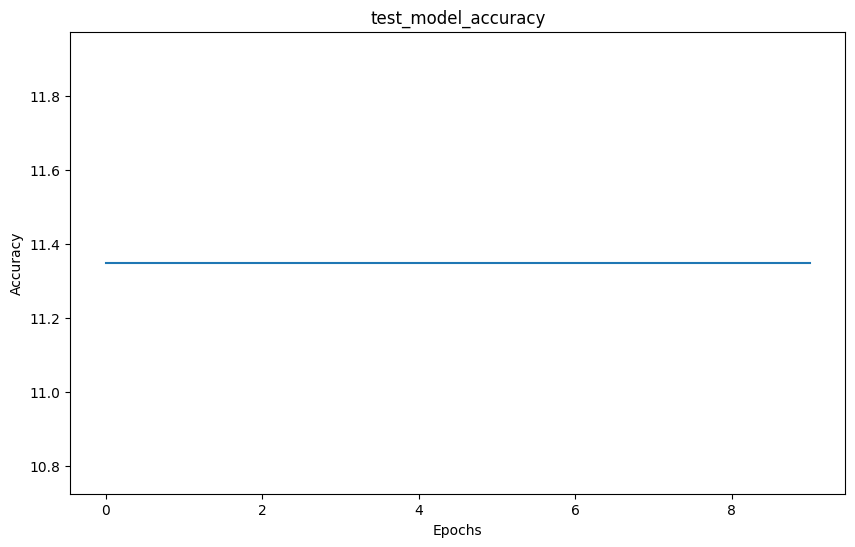

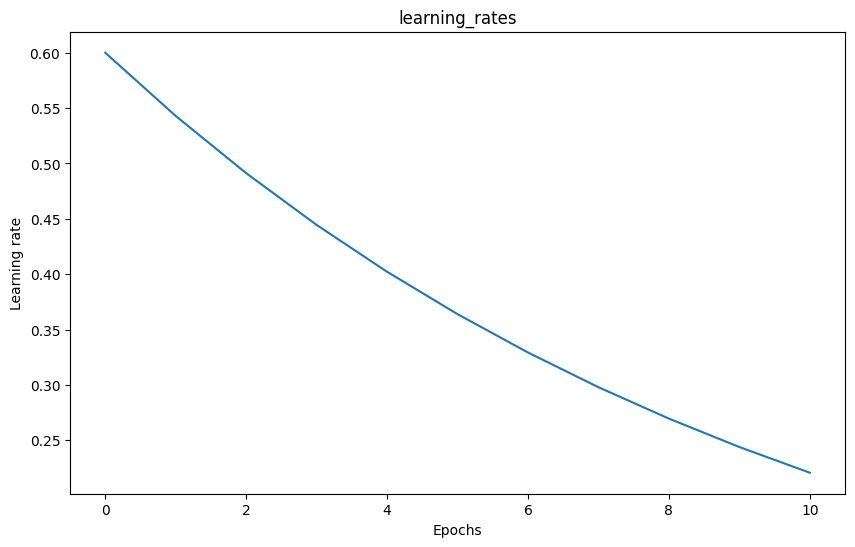

In [12]:

trainer.plot_smthg(trainer.losses, title="test_model_loss", x_title="Epochs", y_title="Loss", save_to="test_model", show=True)
trainer.plot_smthg(trainer.accuracies, title="test_model_accuracy", x_title="Epochs", y_title="Accuracy", save_to="test_model", show=True)
trainer.plot_smthg(trainer.learning_rates, title="learning_rates", x_title="Epochs", y_title="Learning rate", save_to="learning_rates", show=True)

In [13]:
model.export_model("first_try")